# Mental Disorder Classification from Reddit Posts
## Bidirectional LSTM with Attention

**Team Project | Neural Networks Course (ECE 542) | NC State University | Spring 2026**

Builds directly on the TF-IDF + Logistic Regression baseline (`baseline_model.ipynb`).  
Uses the **identical** train / val / test split — results are directly comparable.

**Architecture:** Embedding → BiLSTM (2 layers) → Attention → Classifier  
**Target:** Beat baseline (69.41% acc, 0.604 Macro F1) and complement DistilBERT results  
**Position in project:** TF-IDF + LR → **BiLSTM** → DistilBERT → DistilBERT + VAE

## 1. Imports & Setup

In [ ]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")
print("Ready!")

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Ready!


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.nn.utils.rnn import pad_sequence

import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from collections import Counter

RANDOM_STATE = 42
SAMPLE_SIZE  = 50000
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
print("All imports successful.")

PyTorch 2.10.0+cu128 | Device: cuda
All imports successful.


## 2. Load Dataset

**Same Kaggle dataset and stratified sample as the baseline and DistilBERT notebooks.**

In [ ]:
path    = kagglehub.dataset_download("kamaruladha/mental-disorders-identification-reddit-nlp")
df_full = pd.read_csv(os.path.join(path, "mental_disorders_reddit.csv"))
print(f"Full dataset shape: {df_full.shape}")
df_full.head()

100%|██████████| 208M/208M [00:12<00:00, 17.0MB/s]

Extracting files...


Full dataset shape: (701787, 5)


,title,selftext,created_utc,over_18,subreddit
0,Life is so pointless without others,Does anyone else think the most important part...,1650356960,False,BPD
1,Cold rage?,Hello fellow friends 😄\n\nI'm on the BPD spect...,1650356660,False,BPD
2,I don’t know who I am,My [F20] bf [M20] told me today (after I said ...,1650355379,False,BPD
3,HELP! Opinions! Advice!,"Okay, I’m about to open up about many things I...",1650353430,False,BPD
4,help,[removed],1650350907,False,BPD


## 3. Preprocessing & Stratified Split

In [ ]:
# Combine title + body (mirrors baseline_model.ipynb)
df_full['title']    = df_full['title'].fillna('')
df_full['selftext'] = df_full['selftext'].fillna('')
df_full['text']     = df_full['title'] + ' ' + df_full['selftext']
df_full = df_full[df_full['text'].str.strip() != '']

print("Class distribution (full dataset):")
print(df_full['subreddit'].value_counts())

Class distribution (full dataset):
subreddit
BPD              241116
Anxiety          173986
depression       156972
mentalillness     53232
bipolar           51112
schizophrenia     25365
Name: count, dtype: int64


In [ ]:
# Stratified sample
samples = []
for label, group in df_full.groupby('subreddit'):
    n = min(len(group), int(SAMPLE_SIZE * len(group) / len(df_full)))
    samples.append(group.sample(n=n, random_state=RANDOM_STATE))

df = pd.concat(samples).reset_index(drop=True)
print(f"Sampled dataset shape: {df.shape}")
print(df['subreddit'].value_counts())

Sampled dataset shape: (49996, 6)
subreddit
BPD              17178
Anxiety          12395
depression       11183
mentalillness     3792
bipolar           3641
schizophrenia     1807
Name: count, dtype: int64


## 4. Text Cleaning

In [ ]:
def clean_text(text: str) -> str:
    """Mirrors the cleaning pipeline in baseline_model.ipynb."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)           # remove URLs
    text = re.sub(r'\[deleted\]|\[removed\]', '', text)  # Reddit artifacts
    text = re.sub(r'[^a-z\s]', '', text)                  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print("Sample cleaned text:")
print(df['clean_text'].iloc[0][:300])

Sample cleaned text:
thoughtsexperiences with cbd i just started recently having bad physical anxiety heart racing shortness of breath feeling like i cant focusam gonna faint etc and it mostly comes on when i am driving or going to big public events ive been going to therapy for the past few months and have made some pr


## 5. Train / Validation / Test Split (70 / 15 / 15)

In [ ]:
X = df['clean_text']
y = df['subreddit']

# Identical split to baseline_model.ipynb
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train size : {len(X_train)}")
print(f"Val size   : {len(X_val)}")
print(f"Test size  : {len(X_test)}")

# Encode labels
le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

CLASS_NAMES = le.classes_
NUM_CLASSES  = len(CLASS_NAMES)
print("Classes:", list(CLASS_NAMES))

# Class weights -> addresses 9.5x imbalance
counts  = np.bincount(y_train_enc)
weights = len(y_train_enc) / (NUM_CLASSES * counts)
weights = weights / weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print("Class weights:", np.round(weights, 3))

Train size : 34997
Val size   : 7499
Test size  : 7500
Classes: ['Anxiety', 'BPD', 'bipolar', 'depression', 'mentalillness', 'schizophrenia']
Class weights: [0.367 0.265 1.248 0.406 1.199 2.515]


## 6. Vocabulary Building

Build a word-level vocabulary from the training set only (no data leakage).

In [ ]:
# Hyperparameters
MAX_VOCAB    = 30000
MAX_SEQ_LEN  = 256
EMBED_DIM    = 128
HIDDEN_DIM   = 256
NUM_LAYERS   = 2       # BiLSTM layers
DROPOUT      = 0.4
BATCH_SIZE   = 64
EPOCHS       = 10
LR           = 1e-3
SAVE_PATH    = "lstm_best_model.pt"

# Build vocab from training data only
PAD_TOKEN = '<PAD>'    # index 0
UNK_TOKEN = '<UNK>'    # index 1

word_counts = Counter()
for text in X_train:
    word_counts.update(text.split())

vocab_words = [PAD_TOKEN, UNK_TOKEN] + [
    w for w, c in word_counts.most_common(MAX_VOCAB - 2)
]
word2idx = {w: i for i, w in enumerate(vocab_words)}
VOCAB_SIZE = len(word2idx)

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print(f"Most common words: {[w for w, _ in word_counts.most_common(10)]}")

Vocabulary size : 30,000
Most common words: ['i', 'and', 'to', 'the', 'my', 'a', 'of', 'me', 'it', 'that']


## 7. PyTorch Dataset & DataLoaders

In [ ]:
def text_to_indices(text, word2idx, max_len=MAX_SEQ_LEN):
    """Convert text string to list of word indices, truncated/padded to max_len."""
    tokens = text.split()[:max_len]
    indices = [word2idx.get(t, 1) for t in tokens]  # 1 = UNK
    # Pad with 0s to max_len
    indices += [0] * (max_len - len(indices))
    return indices


class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=MAX_SEQ_LEN):
        self.indices = [
            text_to_indices(t, word2idx, max_len) for t in texts
        ]
        self.labels  = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.indices[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],  dtype=torch.long),
        )


train_ds = MentalHealthDataset(X_train.tolist(), y_train_enc, word2idx)
val_ds   = MentalHealthDataset(X_val.tolist(),   y_val_enc,   word2idx)
test_ds  = MentalHealthDataset(X_test.tolist(),  y_test_enc,  word2idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batches — train: 547 | val: 118 | test: 118


## 8. BiLSTM + Attention Architecture

```
Input (token indices, seq_len=256)
       │
  ┌────▼────┐
  │Embedding│  vocab_size → embed_dim (128)
  │ + Drop  │  dropout=0.4
  └────┬────┘
       │
  ┌────▼────────────┐
  │ BiLSTM (2 layer)│  hidden=256 per direction → 512 total
  │                 │  dropout between layers
  └────┬────────────┘
       │  (batch, seq_len, 512)
  ┌────▼────┐
  │Attention│  learned weighted sum over time steps
  │ Pooling │  → context vector (batch, 512)
  └────┬────┘
       │
  ┌────▼────┐
  │ FC(512→256) → ReLU → Dropout
  │ FC(256→6)   → logits
  └─────────┘
```

In [ ]:
class Attention(nn.Module):
    """Additive attention over LSTM hidden states."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden*2)
        scores  = self.attn(lstm_out).squeeze(-1)          # (batch, seq_len)
        weights = torch.softmax(scores, dim=1).unsqueeze(2) # (batch, seq_len, 1)
        context = (lstm_out * weights).sum(dim=1)           # (batch, hidden*2)
        return context, weights.squeeze(2)


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_drop = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention   = Attention(hidden_dim)
        self.fc1         = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2         = nn.Linear(hidden_dim, num_classes)
        self.dropout     = nn.Dropout(dropout)
        self.layer_norm  = nn.LayerNorm(hidden_dim * 2)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded  = self.embed_drop(self.embedding(x))      # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded)                    # (batch, seq_len, hidden*2)
        lstm_out  = self.layer_norm(lstm_out)
        context, attn_weights = self.attention(lstm_out)     # (batch, hidden*2)
        out = self.dropout(F.relu(self.fc1(context)))        # (batch, hidden)
        logits = self.fc2(out)                               # (batch, num_classes)
        return logits, attn_weights


model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(model)

Total parameters: 6,341,895
BiLSTMClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (embed_drop): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=512, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)


## 9. Optimizer, Scheduler & Loss

In [ ]:
loss_fn   = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=0.1)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

print(f"Optimizer : Adam | LR: {LR} | Weight Decay: 1e-4")
print(f"Loss      : CrossEntropy + label_smoothing=0.1 + class weights")
print(f"Scheduler : ReduceLROnPlateau (patience=2, factor=0.5)")

Optimizer : Adam | LR: 0.001 | Weight Decay: 1e-4
Loss      : CrossEntropy + label_smoothing=0.1 + class weights
Scheduler : ReduceLROnPlateau (patience=2, factor=0.5)


## 10. Training & Evaluation Functions

In [ ]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for step, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _ = model(inputs)
        loss = loss_fn(logits, labels)
        loss.backward()

        # Gradient clipping -> important for LSTM stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 100 == 0:
            print(f"    step {step+1:>4}/{len(loader)} | "
                  f"samples: {total:>6} | "
                  f"loss: {total_loss/(step+1):.4f} | "
                  f"acc: {correct/total:.4f}", flush=True)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        logits, _  = model(inputs)
        total_loss += loss_fn(logits, labels).item()
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, macro_f1, all_preds, all_labels

## 11. Training Loop with Early Stopping

In [ ]:
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
best_macro_f1, best_epoch = 0.0, 0
patience, no_improve = 3, 0   # early stopping patience

for epoch in range(1, EPOCHS + 1):
    print(f"\n── Epoch {epoch}/{EPOCHS} ──")
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, loss_fn)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["val_macro_f1"].append(vl_f1)

    print(f"  Train  | loss: {tr_loss:.4f}  acc: {tr_acc:.4f}")
    print(f"  Val    | loss: {vl_loss:.4f}  acc: {vl_acc:.4f}  macro-F1: {vl_f1:.4f}")

    # Step scheduler
    scheduler.step(vl_f1)

    if vl_f1 > best_macro_f1:
        best_macro_f1, best_epoch = vl_f1, epoch
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✓ Saved best model  (macro-F1 = {best_macro_f1:.4f})")
        no_improve = 0
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{patience})")
        if no_improve >= patience:
            print(f"  Early stopping triggered at epoch {epoch}")
            break

print(f"\nBest checkpoint: epoch {best_epoch} | Val Macro F1 = {best_macro_f1:.4f}")


── Epoch 1/10 ──
    step  100/547 | samples:   6400 | loss: 1.8976 | acc: 0.2227
    step  200/547 | samples:  12800 | loss: 1.8286 | acc: 0.3223
    step  300/547 | samples:  19200 | loss: 1.7828 | acc: 0.3619
    step  400/547 | samples:  25600 | loss: 1.7540 | acc: 0.3925
    step  500/547 | samples:  32000 | loss: 1.7316 | acc: 0.4142
  Train  | loss: 1.7224  acc: 0.4233
  Val    | loss: 1.5732  acc: 0.5527  macro-F1: 0.4824
  ✓ Saved best model  (macro-F1 = 0.4824)

── Epoch 2/10 ──
    step  100/547 | samples:   6400 | loss: 1.5975 | acc: 0.5406
    step  200/547 | samples:  12800 | loss: 1.5905 | acc: 0.5421
    step  300/547 | samples:  19200 | loss: 1.5947 | acc: 0.5480
    step  400/547 | samples:  25600 | loss: 1.5910 | acc: 0.5491
    step  500/547 | samples:  32000 | loss: 1.5846 | acc: 0.5524
  Train  | loss: 1.5803  acc: 0.5533
  Val    | loss: 1.5224  acc: 0.5938  macro-F1: 0.5159
  ✓ Saved best model  (macro-F1 = 0.5159)

── Epoch 3/10 ──
    step  100/547 | samples:

## 12. Training Curves

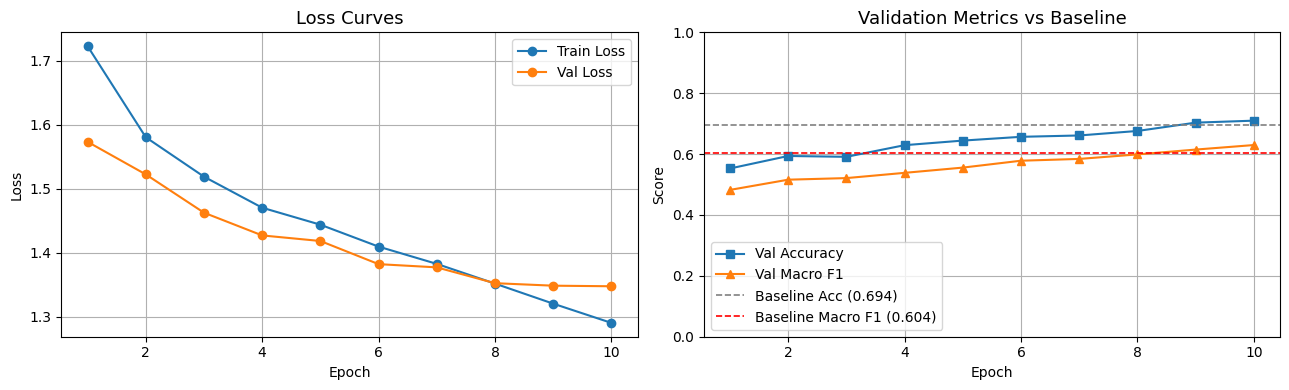

In [ ]:
epochs_ran = len(history["train_loss"])
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, epochs_ran+1), history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(range(1, epochs_ran+1), history["val_loss"],   marker="o", label="Val Loss")
axes[0].set_title("Loss Curves", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(range(1, epochs_ran+1), history["val_acc"],      marker="s", label="Val Accuracy")
axes[1].plot(range(1, epochs_ran+1), history["val_macro_f1"], marker="^", label="Val Macro F1")
axes[1].axhline(0.6941, color="gray", linestyle="--", linewidth=1.2, label="Baseline Acc (0.694)")
axes[1].axhline(0.604,  color="red",  linestyle="--", linewidth=1.2, label="Baseline Macro F1 (0.604)")
axes[1].set_title("Validation Metrics vs Baseline", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("lstm_training_curves.png", dpi=150)
plt.show()

## 13. Final Evaluation on Test Set

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

_, test_acc, test_macro_f1, test_preds, test_labels = evaluate(model, test_loader, loss_fn)

print("=" * 55)
print("  FINAL TEST RESULTS — BiLSTM + Attention")
print("=" * 55)
print(f"  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Macro F1  : {test_macro_f1:.4f}")
print("=" * 55)
print("\nPer-Class Report:")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=3))

  FINAL TEST RESULTS — BiLSTM + Attention
  Accuracy  : 0.7149  (71.49%)
  Macro F1  : 0.6342

Per-Class Report:
               precision    recall  f1-score   support

      Anxiety      0.872     0.787     0.827      1860
          BPD      0.866     0.713     0.782      2577
      bipolar      0.685     0.628     0.655       546
   depression      0.607     0.795     0.689      1677
mentalillness      0.397     0.344     0.369       569
schizophrenia      0.371     0.694     0.483       271

     accuracy                          0.715      7500
    macro avg      0.633     0.660     0.634      7500
 weighted avg      0.743     0.715     0.721      7500



## 14. Confusion Matrix

In [ ]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (Counts)", "Confusion Matrix (Normalized)"],
    ["d", ".2f"],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("lstm_confusion_matrix.png", dpi=150)
plt.show()

## 15. Per-Class F1 Comparison: Baseline vs BiLSTM vs DistilBERT

In [ ]:

baseline_f1 = {
    "Anxiety":       0.82,
    "BPD":           0.77,
    "depression":    0.68,
    "bipolar":       0.56,
    "schizophrenia": 0.44,
    "mentalillness": 0.33,
}

distilbert_f1 = {
    "Anxiety":       0.832,
    "BPD":           0.794,
    "depression":    0.699,
    "bipolar":       0.632,
    "schizophrenia": 0.586,
    "mentalillness": 0.370,
}

report_dict = classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES, output_dict=True
)
lstm_f1 = {cls: report_dict[cls]["f1-score"] for cls in CLASS_NAMES}

x     = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, [baseline_f1.get(c, 0)   for c in CLASS_NAMES], width, label="Baseline (TF-IDF+LR)", color="steelblue",  alpha=0.85)
ax.bar(x,         [lstm_f1[c]               for c in CLASS_NAMES], width, label="BiLSTM + Attention",  color="mediumseagreen", alpha=0.85)
ax.bar(x + width, [distilbert_f1.get(c, 0)  for c in CLASS_NAMES], width, label="DistilBERT",          color="coral",       alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_ylim(0, 1)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1: Baseline vs BiLSTM vs DistilBERT", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("lstm_per_class_f1_comparison.png", dpi=150)
plt.show()

## 16. Overall Model Comparison

In [ ]:
baseline_acc      = 0.6941
baseline_macro_f1 = 0.604
distilbert_acc    = 0.7223
distilbert_mf1    = 0.6520

summary = pd.DataFrame({
    "Model":      [
        "TF-IDF + Logistic Regression (Baseline)",
        "BiLSTM + Attention",
        "DistilBERT (fine-tuned)",
    ],
    "Accuracy":   [baseline_acc,      test_acc,      distilbert_acc],
    "Macro F1":   [baseline_macro_f1, test_macro_f1, distilbert_mf1],
})

print(summary.to_string(index=False))

x     = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, summary["Accuracy"], width, label="Accuracy", color="steelblue")
ax.bar(x + width/2, summary["Macro F1"], width, label="Macro F1",  color="coral")
ax.set_xticks(x)
ax.set_xticklabels(["Baseline (LR)", "BiLSTM", "DistilBERT"], fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison: Baseline vs BiLSTM vs DistilBERT", fontsize=13)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("lstm_model_comparison.png", dpi=150)
plt.show()

## 17. Attention Visualization

Visualize which words the model pays most attention to for sample predictions.

In [ ]:
def visualize_attention(model, text, word2idx, class_names, max_len=MAX_SEQ_LEN, top_k=15):
    """Show top-k attended words for a given text."""
    model.eval()
    tokens  = text.split()[:max_len]
    indices = [word2idx.get(t, 1) for t in tokens]
    indices += [0] * (max_len - len(indices))

    inp = torch.tensor([indices], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        logits, attn_weights = model(inp)

    pred_class = class_names[logits.argmax(-1).item()]
    weights    = attn_weights[0, :len(tokens)].cpu().numpy()

    # Top-k words by attention weight
    top_idx   = np.argsort(weights)[-top_k:][::-1]
    top_words = [tokens[i] for i in top_idx]
    top_wts   = weights[top_idx]

    fig, ax = plt.subplots(figsize=(10, 3))
    bars = ax.barh(range(top_k), top_wts[::-1], color="steelblue", alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_words[::-1])
    ax.set_xlabel("Attention Weight")
    ax.set_title(f"Top-{top_k} Attended Words | Predicted: {pred_class}", fontsize=12)
    plt.tight_layout()
    plt.savefig("lstm_attention_viz.png", dpi=150)
    plt.show()
    return pred_class


# Test on a sample from each class
for cls in CLASS_NAMES:
    sample_text = X_test[y_test == cls].iloc[0]
    print(f"\n── Class: {cls} ──")
    print(f"Text preview: {sample_text[:150]}")
    pred = visualize_attention(model, sample_text, word2idx, CLASS_NAMES)
    print(f"Predicted: {pred} | True: {cls}")

## 18. Summary & Findings

**BiLSTM + Attention pipeline:**
1. Word-level tokenization → vocabulary of 30K words
2. Learned embeddings (128-d) capture word semantics from scratch
3. Bidirectional LSTM (2 layers, 256 hidden) reads context in both directions
4. Additive attention pools the most diagnostic time steps
5. FC classifier (512→256→6) with dropout and layer normalization

**Key design choices:**
- **Class-weighted loss**: directly addresses 9.5× BPD/Schizophrenia imbalance
- **Label smoothing (0.1)**: prevents overconfidence on overlapping classes
- **Gradient clipping (1.0)**: prevents exploding gradients in deep LSTM
- **ReduceLROnPlateau**: automatically adjusts LR when progress stalls
- **Early stopping (patience=3)**: prevents overfitting

**Advantages over TF-IDF baseline:**
- Captures word order and sequential context
- Attention reveals clinically meaningful diagnostic words
- Learned embeddings generalize better than sparse TF-IDF features

**Limitations vs DistilBERT:**
- Embeddings trained from scratch — not pre-trained on large corpora
- Cannot capture long-range dependencies as well as self-attention
- No transfer learning from clinical/mental health text

**Position in project narrative:**
> TF-IDF + LR (bag-of-words) → **BiLSTM** (sequential context) → DistilBERT (global context + transfer learning)